In [1]:
from fastai.vision.all import * 

In [2]:
import torch.nn as nn
import torch

In [3]:
from make import load_secondary_data, load_heath_assessment_test_data
spec, labels = load_secondary_data()

Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall


In [4]:
len(spec)

600

In [5]:
from validation_util import split

valid, valid_labels = load_heath_assessment_test_data()

Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 

In [6]:
class CNN1D(nn.Module):
    def __init__(self, n_classes: int, target_hw=(112, 112)):
        super().__init__()
        self.target_hw = target_hw
        
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),
        )
        
        # Infer flattened size automatically
        with torch.no_grad():
            dummy = torch.zeros(1, 3, *self.target_hw)
            out = self.feature_extractor(dummy)
            self.flattened_size = out.view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.flattened_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes),   # raw logits for CrossEntropyLoss
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        return self.classifier(x)

In [7]:
# constants you can tweak once
FLOOR_DB   = -45.0          # dynamic‑range floor, in dB
TARGET_HW  = (112,112)     # (H, W)
TARGET_CH = 6
EPS = 1e-12
RESIZE_HW  = None

In [8]:
import matplotlib.pyplot as plt
import numpy as np

In [9]:
def get_x(i : int):
        arr = spec[i]

        if arr.ndim == 3:
                arr = np.mean(arr, axis=-1)  # (H, W)

        # Ensure float32
        arr = arr.astype(np.float32)

        # If not already in dB, convert. If it *is* already in dB, skip this block.
        #arr = np.maximum(arr, EPS)
        #arr_db = 10.0 * np.log10(arr)

        # Apply dynamic range floor and normalize to [0,1]
        arr = arr - arr.max()
        arr = np.clip(arr, FLOOR_DB, 0.0)
        arr_01 = (arr - FLOOR_DB) / (-FLOOR_DB)

        arr_01 = arr_01.astype(np.float32)

        arr_01 = arr_01 ** 0.9

        arr_01 = np.flipud(arr_01)

        cmap = plt.get_cmap('magma')
        img_rgb = cmap(arr_01)[:, :, :3]


        # Convert to tensor and make 3-channel (grayscale -> RGB-style)
        t = torch.from_numpy(img_rgb)          # (H, W)
        t = t.float().permute(2, 0, 1).unsqueeze(0)    # (3, H, W)

        # Add batch dimension for interpolate
        #t = t.unsqueeze(0)                    # (1, 3, H, W)

        # Resize
        t_resized = F.interpolate(
                t, size=TARGET_HW, mode='bilinear', align_corners=False
        )

        return TensorImage(t_resized.squeeze(0))  # (3, H, W)

def get_y(i):
    return labels[i]

In [10]:
block = DataBlock(
    blocks=(TransformBlock(), CategoryBlock(sort=False)),
    get_items=lambda x: x,
    get_x=get_x,
    get_y=get_y,
)

In [11]:
items = list(range(len(spec)))   # or `range(N)`
dls = block.dataloaders(items, bs=12)

In [12]:
model = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, stride=2),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),
            
            nn.Conv2d(8, 16, kernel_size=3, stride=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),

            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(16*6*6, 14),   # raw logits for CrossEntropyLoss
        )

In [13]:
learner = Learner(dls, model, loss_func=CrossEntropyLossFlat(), metrics=accuracy)

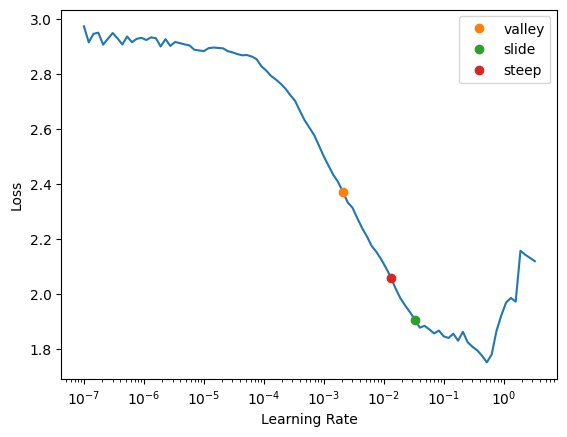

In [14]:
lr = learner.lr_find(suggest_funcs=(valley,slide,steep))

In [15]:
learner.fine_tune(20)

epoch,train_loss,valid_loss,accuracy,time
0,1.482564,1.002697,0.550000,00:00


epoch,train_loss,valid_loss,accuracy,time
0,0.927373,0.798547,0.683333,00:00
1,0.859678,0.721399,0.733333,00:00
2,0.796109,0.664080,0.791667,00:00
3,0.732113,0.623900,0.758333,00:00
4,0.673837,0.570995,0.783333,00:00
5,0.617058,0.517994,0.800000,00:00
6,0.591559,0.512903,0.800000,00:00
7,0.558605,0.484851,0.791667,00:00
8,0.516884,0.463647,0.816667,00:00
9,0.478407,0.444905,0.858333,00:00


In [16]:
learner.unfreeze()

In [17]:
learner.fit_one_cycle(30, lr.valley)

In [18]:
dir = Path('./models')

learner.path = dir

learner.export('hybrid.pkl')

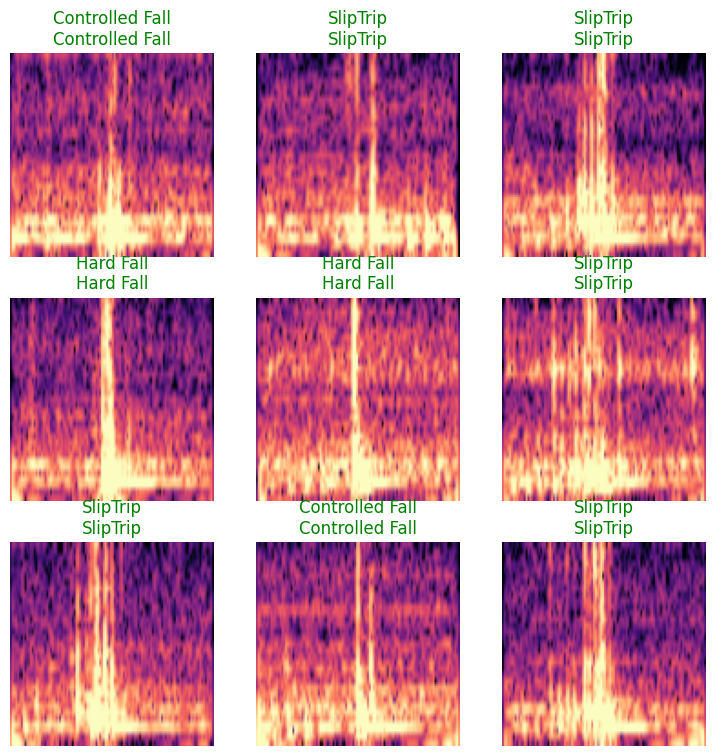

In [19]:
learner.show_results()

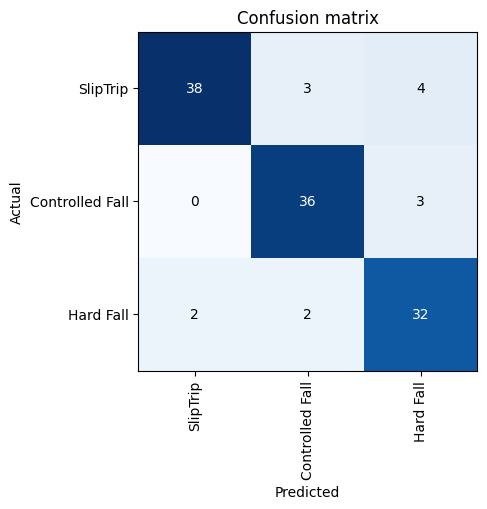

In [20]:
inter_plot = ClassificationInterpretation.from_learner(learner)
inter_plot.plot_confusion_matrix(figsize=(5,5))

In [21]:
def get_x_test(i):
    arr = valid[i]

    if arr.ndim == 3:
        arr = np.mean(arr, axis=-1)  # (H, W)

    # Ensure float32
    arr = arr.astype(np.float32)

    # If not already in dB, convert. If it *is* already in dB, skip this block.
    #arr = np.maximum(arr, EPS)
    #arr_db = 10.0 * np.log10(arr)

    # Apply dynamic range floor and normalize to [0,1]
    arr = arr - arr.max()
    arr = np.clip(arr, FLOOR_DB, 0.0)
    arr_01 = (arr - FLOOR_DB) / (-FLOOR_DB)

    arr_01 = arr_01.astype(np.float32)

    arr_01 = arr_01 ** 0.9

    arr_01 = np.flipud(arr_01)

    cmap = plt.get_cmap('magma')
    img_rgb = cmap(arr_01)[:, :, :3]


    # Convert to tensor and make 3-channel (grayscale -> RGB-style)
    t = torch.from_numpy(img_rgb)          # (H, W)
    t = t.float().permute(2, 0, 1).unsqueeze(0)    # (3, H, W)

    # Add batch dimension for interpolate
    #t = t.unsqueeze(0)                    # (1, 3, H, W)

    # Resize
    t_resized = F.interpolate(
        t, size=TARGET_HW, mode='bilinear', align_corners=False
    )

    return TensorImage(t_resized.squeeze(0))  # (3, H, W)


def get_y_test(i):
    return valid_labels[i]

In [22]:
learner.validate()

(#2) [0.3202550709247589,0.8833333253860474]

In [23]:
def get_y_pred(learner: Learner, val_set : list):
    y_pred = []
    y_test = []
    
    for i in range(len(val_set)):
        y_pred.append(learner.predict(get_x_test(i))[0])
        y_test.append(get_y_test(i))
    return y_pred, y_test 

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [25]:
y_pred, y_test = get_y_pred(learner, valid)

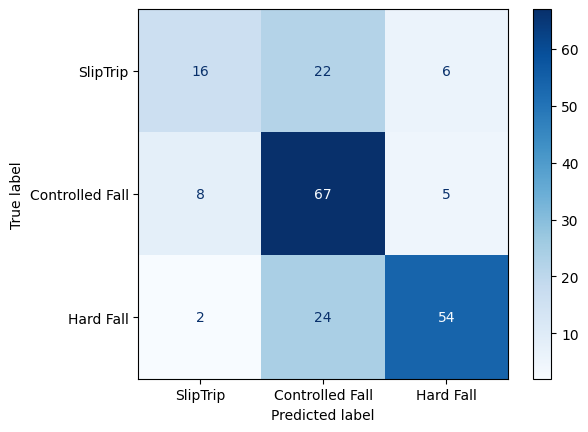

In [26]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=dls.vocab)
disp.plot(cmap="Blues")  # customize as you like
plt.show()

In [27]:
accuracy_score(y_test, y_pred)

0.6715686274509803

In [28]:
precision_score(y_test, y_pred, average='weighted')

0.6910396561619883

In [29]:
recall_score(y_test, y_pred, average="weighted")

0.6715686274509803

In [30]:
f1_score(y_test, y_pred, average="weighted")

0.6629634022628169